# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-6: Teletransportación Cuántica (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-6.

La teletransportación cuántica transmite el estado de un qubit de Alice a Bob sin enviar el qubit físicamente, usando entrelazamiento y comunicación clásica.

**Qubits:**
- **Q1** — qubit de Alice con el estado |ψ⟩ a transmitir
- **Q2** — qubit de control de Alice (Bell pair)
- **Q3** — qubit de control de Bob (Bell pair)

**Pasos del algoritmo:**
1. Preparar Q1 en el estado |ψ⟩ a transmitir
2. Crear el estado de Bell entre Q2 y Q3: H(Q2) → CNOT(Q2, Q3)
3. CNOT(Q1, Q2) — entrelazar el qubit de Alice con el par de Bell
4. H(Q1) — proyectar Q1 en la base +/−
5. Medir Q1 y Q2 → resultados clásicos M1, M2
6. Correcciones en Q3: CNOT(Q2→Q3) si M2=1, CZ(Q1→Q3) si M1=1
7. Medir Q3 — debe reproducir la distribución de |ψ⟩

### Erratas del libro corregidas

| Libro | Corrección | Motivo |
|---|---|---|
| `elif 'Y': cirq.X(Q1)` | `cirq.Y(Q1)` | Copia-pega del bloque X |
| Variable `cirquit` | `circuit` | Errata tipográfica |

### Implementación

In [1]:
import cirq


def quantum_teleportation(qubit_to_send_op='H', num_copies=100):
    """
    Simula la teletransportación cuántica de Q1 (Alice) a Q3 (Bob).

    qubit_to_send_op: estado a transmitir — 'H', 'X', 'Y', 'Z' o 'I'
    num_copies: número de repeticiones de la simulación
    """
    Q1, Q2, Q3 = [cirq.LineQubit(i) for i in range(3)]
    circuit = cirq.Circuit()

    # Paso 1: preparar el estado a transmitir en Q1
    if qubit_to_send_op == 'H':
        circuit.append(cirq.H(Q1))
    elif qubit_to_send_op == 'X':
        circuit.append(cirq.X(Q1))
    elif qubit_to_send_op == 'Y':
        circuit.append(cirq.Y(Q1))  # libro: cirq.X(Q1) — errata corregida
    elif qubit_to_send_op == 'Z':
        circuit.append(cirq.Z(Q1))
    elif qubit_to_send_op == 'I':
        circuit.append(cirq.I(Q1))
    else:
        raise NotImplementedError(f"Operador '{qubit_to_send_op}' no implementado")

    # Paso 2: Bell pair entre Q2 y Q3
    circuit.append(cirq.H(Q2))
    circuit.append(cirq.CNOT(Q2, Q3))

    # Paso 3: CNOT entre Q1 (control) y Q2 (objetivo)
    circuit.append(cirq.CNOT(Q1, Q2))

    # Paso 4: Hadamard en Q1
    circuit.append(cirq.H(Q1))

    # Paso 5: medir Q1 y Q2 (Alice)
    circuit.append(cirq.measure(Q1, Q2))

    # Paso 6: correcciones en Q3 (Bob)
    circuit.append(cirq.CNOT(Q2, Q3))
    circuit.append(cirq.CZ(Q1, Q3))

    # Paso 7: medir Q3 (Bob)
    circuit.append(cirq.measure(Q3, key='Z'))

    return circuit

### Circuito — estado transmitido: |+⟩ (Hadamard)

In [2]:
circuit = quantum_teleportation(qubit_to_send_op='H')
print(circuit)

0: ───H───────@───H───M───────@────────────
              │       │       │
1: ───H───@───X───────M───@───┼────────────
          │               │   │
2: ───────X───────────────X───@───M('Z')───


### Visualización del circuito

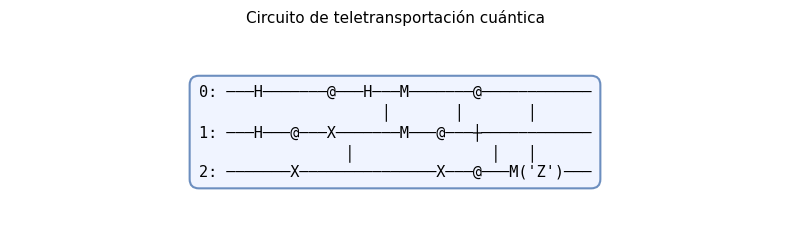

In [3]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=11,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Circuito de teletransportación cuántica', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Simulación

In [4]:
sim = cirq.Simulator()
output = sim.run(circuit, repetitions=100)

print("Resultado de medición en Q3 (Bob):")
print(output.histogram(key='Z'))

Resultado de medición en Q3 (Bob):
Counter({1: 53, 0: 47})


### Histograma — Q3 (Bob)

Si la teletransportación es correcta, Q3 debe reproducir la distribución del estado transmitido.
Para |+⟩ (Hadamard) esperamos ~50% |0⟩ y ~50% |1⟩.

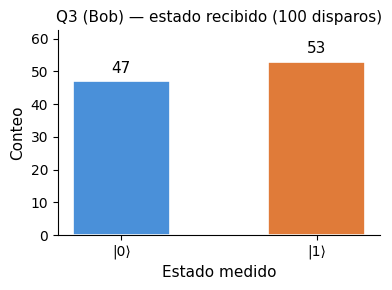

In [5]:
from qml_santanu.common.plot_utils import plot_counts

plot_counts(output.histogram(key='Z'), title='Q3 (Bob) — estado recibido')

### Experimento: distintos estados de Alice

Cambiando `qubit_to_send_op` podemos verificar la teletransportación para otros estados:

| Operador | Estado transmitido | Resultado esperado en Q3 |
|---|---|---|
| `'H'` | $\|+\rangle = \frac{1}{\sqrt{2}}(\|0\rangle+\|1\rangle)$ | ~50% \|0⟩, ~50% \|1⟩ |
| `'I'` | $\|0\rangle$ | ~100% \|0⟩ |
| `'X'` | $\|1\rangle$ | ~100% \|1⟩ |


Operador: I


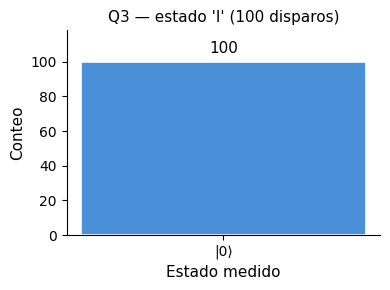


Operador: X


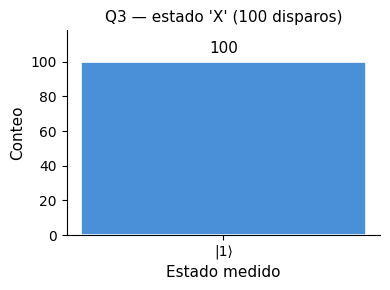

In [7]:
for op in ['I', 'X']:
    c = quantum_teleportation(qubit_to_send_op=op)
    out = sim.run(c, repetitions=100)
    print(f"\nOperador: {op}")
    plot_counts(out.histogram(key='Z'), title=f"Q3 — estado '{op}'")